# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.integrate import quad
%matplotlib ipympl
G = 6.67 * 10 **-11
g = 9.81 #m/s^2
Me = 5.9 * 10**24 #kg
MM = 7.3 * 10**22 #kg
Mass_Apollo = 5500 #kg
RE = 6378000 #m
RM = 1737000 #m
dEM = 3.8 * 10**8 #m
ve = 2.4 * 10**3 #m/s
mdot = 1.3 * 10**4 #kg/s
m0 = 2.8 * 10**6 #kg
mf = 7.5 * 10**5 #kg

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [2]:
def gravitational_potential(M: float, xM: float, yM: float , x: float, y: float) -> float:
    """
    Purpose: Calculate the gravitational potential of a body

    Args: M, xM, yM, x, y

    Raises: ValueError if any values are non-finite

    Returns: the gravitational potential of a body
    """

    # type-checks
    x = np.asarray(x)
    y = np.asarray(y)
    M = np.asarray(M)
    xM = np.asarray(xM)
    yM = np.asarray(yM)
    
    # calculating radius from body
    x_diff = x - xM
    y_diff = y - yM
    r = np.sqrt(x_diff**2 + y_diff**2)

    # calculating gravitational potential
    answer = -G*M / r

    # post-condition
    if not np.all(np.isfinite(answer)):
        raise ValueError('The potential contains non-finite values.')
    return answer
    
# calling function
answer = gravitational_potential(M = Me, xM = 4, yM = 3, x = 2, y = 1)
print(answer)

-139133865800171.02


<!-- 2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$. -->
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

Text(0.5, 1.0, 'Gravitational Potential based on Distance')

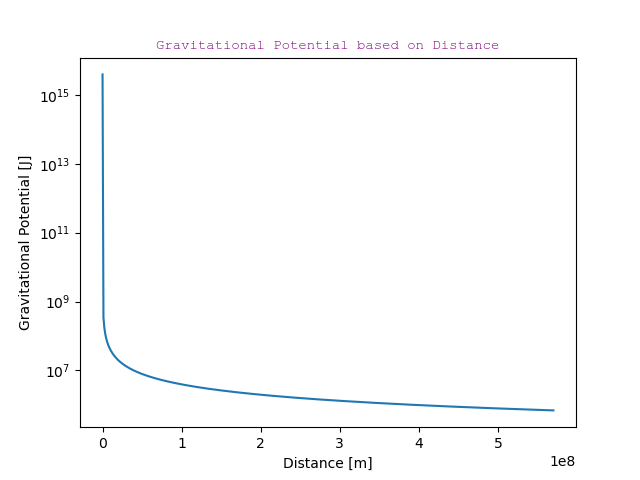

In [3]:
# setting the x values
x = np.linspace(0.1, dEM * 1.5, 500)
Px = np.ones(len(x))

# inputting the x value to calculate gravitational potential
for i in range(len(x)):
    Px[i] = gravitational_potential(Me, 0.0, 0.0, x[i], 0.0)

# plotting the graph
fig, ax = plt.subplots()
ax.plot(x, abs(Px))
ax.set_yscale('log')
ax.set_ylabel('Gravitational Potential [J]')
ax.set_xlabel('Distance [m]')
ax.set_title('Gravitational Potential based on Distance', fontname = 'courier new', fontsize = 10, color = 'purple')

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

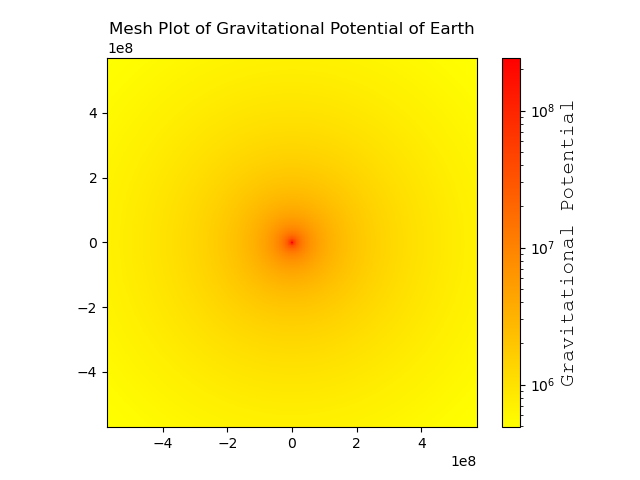

In [4]:
# Setting x and y intervals
x = np.linspace(dEM * -1.5, dEM * 1.5, 500)
y = np.linspace(dEM * -1.5, dEM * 1.5, 500)

# converting to 2d arrays
X, Y = np.meshgrid(x,y)

# calling the function
p_val = gravitational_potential(Me, 0, 0, X, Y)

# drawing the graph
plt.close('all')
fig, ax = plt.subplots()
mesh = ax.pcolormesh(X, Y, np.abs(p_val), norm = LogNorm(), cmap = 'autumn_r')
ax.set_aspect('equal')
ax.set_title('Mesh Plot of Gravitational Potential of Earth')
cbar = fig.colorbar(mesh)
cbar.set_label('Gravitational Potential', fontname = 'courier new', fontsize = 15)

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

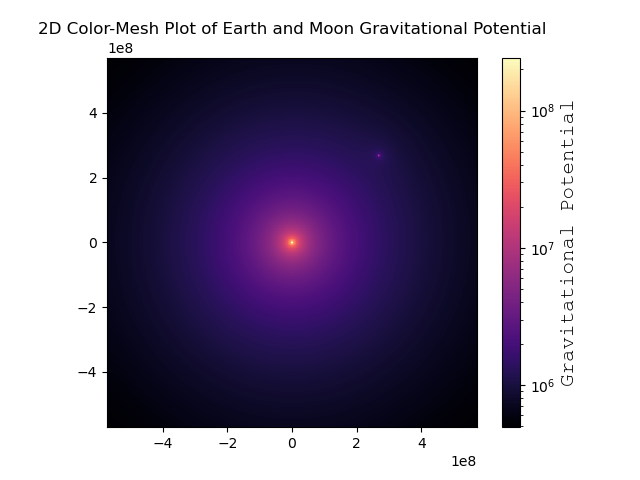

In [5]:
# Setting x and y intervals
x = np.linspace(dEM * -1.5, dEM * 1.5, 500)
y = np.linspace(dEM * -1.5, dEM * 1.5, 500)

# converting to 2d arrays
X, Y = np.meshgrid(x,y)

# xm and ym
moon_loc1 = dEM / np.sqrt(2)
moon_loc2 = dEM / np.sqrt(2)

# calling the function
p_val = gravitational_potential(Me, 0, 0, X, Y)
p_val2 = gravitational_potential(MM, moon_loc1, moon_loc2, X, Y)
p_val3 = p_val + p_val2

# drawing the graph
plt.close('all')
fig, ax = plt.subplots()
mesh = ax.pcolormesh(X, Y, np.abs(p_val3), norm = LogNorm(), cmap = 'magma')
ax.set_aspect('equal')
ax.set_title('2D Color-Mesh Plot of Earth and Moon Gravitational Potential')
cbar = fig.colorbar(mesh)
cbar.set_label('Gravitational Potential', fontname = 'courier new', fontsize = 15)

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

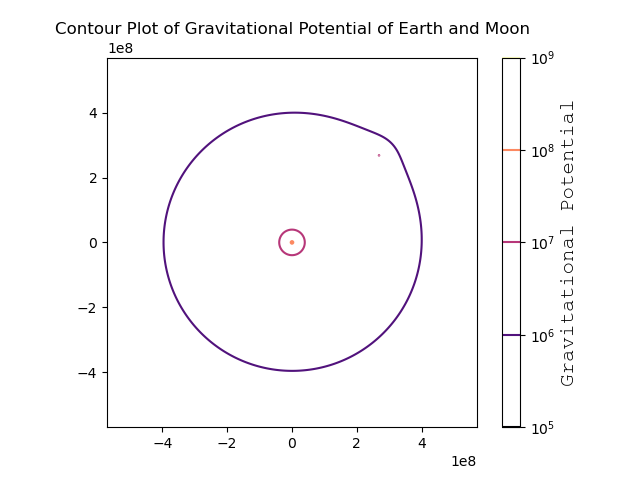

In [6]:
# Setting x and y intervals
x = np.linspace(dEM * -1.5, dEM * 1.5, 500)
y = np.linspace(dEM * -1.5, dEM * 1.5, 500)

# converting to 2d arrays
X, Y = np.meshgrid(x,y)

# xm and ym
moon_loc1 = dEM / np.sqrt(2)
moon_loc2 = dEM / np.sqrt(2)

# calling the function
p_val = gravitational_potential(Me, 0, 0, X, Y)
p_val2 = gravitational_potential(MM, moon_loc1, moon_loc2, X, Y)
p_val3 = p_val + p_val2

# drawing the graph
plt.close('all')
fig, ax = plt.subplots()
surf = ax.contour(X, Y, np.abs(p_val3), cmap = 'magma', levels = 500, norm = LogNorm())
ax.set_aspect('equal')
ax.set_title('Contour Plot of Gravitational Potential of Earth and Moon')
cbar = fig.colorbar(surf)
cbar.set_label('Gravitational Potential', fontname = 'courier new', fontsize = 15)

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [7]:
def gravitational_force(M1: float, m2: float, x1: float, y1: float, x2: float, y2: float) -> tuple[float, float]:
    """ 
    Purpose: This function determines the gravitational force between two bodies

    Args: M1 and m2, the mass of the first and second bodies, respectively, x1 and y1, the position of M1, and x2 and y2, the position of m2

    Raises: ValueError if F_vector contains non-finite values (if r_displacement = 0)

    Returns: F_xvector, F_yvector, the x and y vector components of the gravitational force
    """
    # converting to arrays
    M1 = np.asarray(M1)
    m2 = np.asarray(m2)
    x1 = np.asarray(x1)
    y1 = np.asarray(y1)
    x2 = np.asarray(x2)
    y2 = np.asarray(y2)
    
    # calculating the displacements
    x_displacement = x2 - x1
    y_displacement = y2 - y1
    r_displacement = np.sqrt(x_displacement**2 + y_displacement**2)
    
    # avoiding the singularity
    r_displacement = np.where(r_displacement == 0, np.nan, r_displacement)
    
    # calculating the force
    F_vector = -G * ((M1 * m2) / (r_displacement)**2) * r_displacement

    # theta calculation
    theta = np.arctan2(y_displacement, x_displacement)

    # x and y components of the force
    F_xvector = F_vector * np.cos(theta)
    F_yvector = F_vector * np.sin(theta)

    # raising error if not finite, returning answer
    if not np.all(np.isfinite(F_vector)):
        raise ValueError('The force contains non-finite values.')
    return F_xvector, F_yvector
    

F_xvector, F_yvector = gravitational_force(10, 1, 0, 0, 5, 5)
print(F_xvector, F_yvector)

-6.67e-11 -6.669999999999999e-11


2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

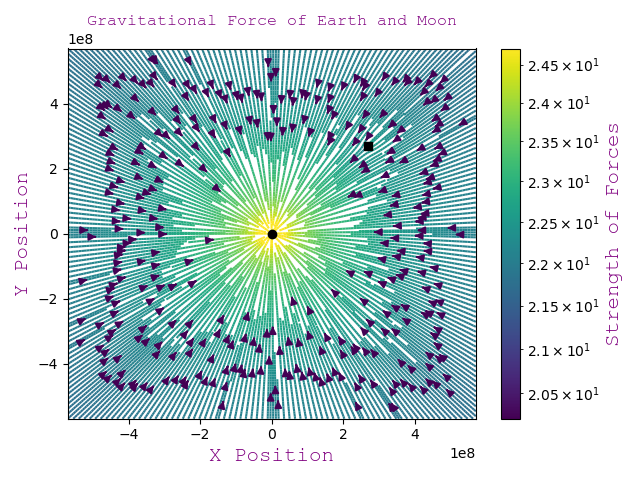

In [8]:
# Setting x and y intervals
x = np.linspace(dEM * -1.5, dEM * 1.5, 500)
y = np.linspace(dEM * -1.5, dEM * 1.5, 500)

# converting to 2d arrays
X, Y = np.meshgrid(x,y)

# calling the function
gravforcex, gravforcey = gravitational_force(M1 = Me, m2 = Mass_Apollo, x1 = 0, y1 = 0, x2 = X, y2 = Y)
gravforcex2, gravforcey2 = gravitational_force(M1 = MM, m2 = Mass_Apollo, x1 = dEM / np.sqrt(2), y1 = dEM / np.sqrt(2), x2 = X, y2 = Y)

# summing the forces
sumgravforcex = gravforcex + gravforcex2
sumgravforcey = gravforcey + gravforcey2

# streamplot creation
plt.close('all')
fig, ax = plt.subplots()
colors = np.log(np.hypot(sumgravforcex, sumgravforcey))
stream = ax.streamplot(X, Y, sumgravforcex, sumgravforcey, color = colors, density = 5, norm = LogNorm()) 
ax.set_xlabel('X Position', color = 'purple', fontname = 'courier new', fontsize = 15)
ax.set_ylabel('Y Position', color = 'purple', fontname = 'courier new', fontsize = 15)
ax.set_title('Gravitational Force of Earth and Moon', color = 'purple', fontname = 'courier new')
ax.plot(0, 0, marker = 'o', color = 'black')
ax.plot(dEM/np.sqrt(2), dEM/np.sqrt(2), marker = 's', color = 'black', markersize = 6)

# colorbar
cbar = fig.colorbar(stream.lines)
cbar.set_label('Strength of Forces', fontname = 'courier new', color = 'Purple', fontsize = 15)
fig.tight_layout()

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

First, we'll be using this. 
$F = G \frac{M_m}{r^2}$

Plugging in the moon and Earth on either side, we get:

$\frac{M_E}{r^2}= \frac{M_Mm}{(d_{EM}-r)^2}$

Next, I'll cancel the stuff that cancels

$\frac{M_E}{r^2} = \frac{M_M}{(d_{EM}-r)^2}$

Next, I'll multiply by $r^2$ and move some stuff around so r is on one side

$\sqrt{\frac{M_E}{M_M}} = \frac{d_{EM}-r}{r}$

After that, I'll move r over and factor it out

$r(1+\sqrt{\frac{M_E}{M_M}}) = d_{EM}$

Finally, make r by itself. We did it!

$r = \frac{d_{EM}}{1+\sqrt{\frac{M_E}{M_M}}}$

And your updated plot, including the balance point, goes in the cell below.

38037653.08818483


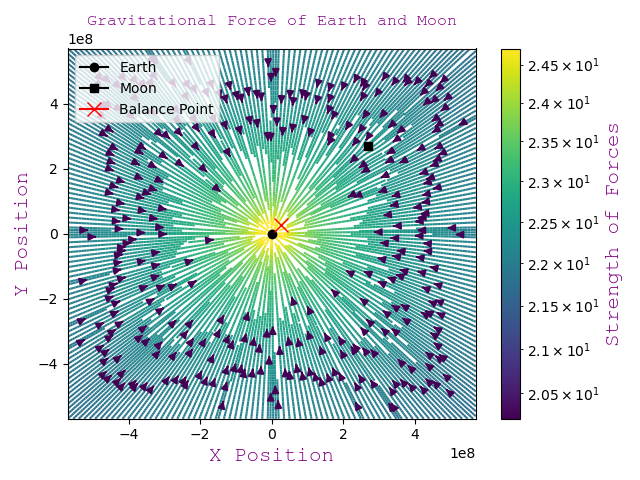

In [9]:
# Setting x and y intervals
x = np.linspace(dEM * -1.5, dEM * 1.5, 500)
y = np.linspace(dEM * -1.5, dEM * 1.5, 500)

# converting to 2d arrays
X, Y = np.meshgrid(x,y)

# calling the function
gravforcex, gravforcey = gravitational_force(M1 = Me, m2 = Mass_Apollo, x1 = 0, y1 = 0, x2 = X, y2 = Y)
gravforcex2, gravforcey2 = gravitational_force(M1 = MM, m2 = Mass_Apollo, x1 = dEM / np.sqrt(2), y1 = dEM / np.sqrt(2), x2 = X, y2 = Y)

# summing the forces
sumgravforcex = gravforcex + gravforcex2
sumgravforcey = gravforcey + gravforcey2

# streamplot creation
plt.close('all')
fig, ax = plt.subplots()
colors = np.log(np.hypot(sumgravforcex, sumgravforcey))
stream = ax.streamplot(X, Y, sumgravforcex, sumgravforcey, color = colors, density = 5, norm = LogNorm()) 
ax.set_xlabel('X Position', color = 'purple', fontname = 'courier new', fontsize = 15)
ax.set_ylabel('Y Position', color = 'purple', fontname = 'courier new', fontsize = 15)
ax.set_title('Gravitational Force of Earth and Moon', color = 'purple', fontname = 'courier new')
ax.plot(0, 0, marker = 'o', color = 'black', label = 'Earth')
ax.plot(dEM/np.sqrt(2), dEM/np.sqrt(2), marker = 's', color = 'black', markersize = 6, label = 'Moon')

# BALANCE POINT
# since we know the moon is 45 degrees relative to the Earth,
# we can use that to find the x and y coordinates.
r = dEM / (1 + (np.sqrt(Me/MM)))
angle = np.pi / 4
balance_x = r * np.cos(angle)
balance_y = r * np.sin(angle)
ax.plot(balance_x, balance_y, marker = 'x', color = 'r', markersize = 10, label = 'Balance Point')
ax.legend(loc = 'upper left')
print(r)

# colorbar
cbar = fig.colorbar(stream.lines)
cbar.set_label('Strength of Forces', fontname = 'courier new', color = 'Purple', fontsize = 15)
fig.tight_layout()

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

The balance point is very close to Earth. It is approximately 38037653.088 meters away from Earth. this makes sense, since Earth is much more massive than the Moon.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [10]:
T = (m0 - mf) / mdot
print(f"""{T} seconds""")

157.69230769230768 seconds


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [11]:
def velocity_change(T, m0, mf, mdot, ve, g):
    """
    Purpose: Calcualate the velocity change from a rocket

    Args: T time, m0 wet mass, mf dry mass, mdot burn rate, ve exhaust velocity, g gravitational constant

    Raises: 
        ValueError if m0 - mdot * T <= 0
        ValueError if T < 0
        ValueError if m0 <= mf
        ValueError if mdot <= 0

    Returns: change_vt, the change in velocity
    """

    # error checking
    if m0 - mdot * T <= 0:
        raise ValueError('Error. Log of a number equal to or less than 0 is undefined.')
    if T < 0:
        raise ValueError('T cannot be less than 0.')
    if m0 <= mf:
        raise ValueError('mf must be greater than m0.')
    if mdot <= 0:
        raise ValueError('mdot must be greater than 0.')

    # ensuring that mass doesn't go below final mass
    m = max(m0 - mdot * T, mf)

    #calculating vt, returning
    change_vt = ve * np.log(m0 / m) - g * T
    return change_vt

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [12]:
integral, err = quad(velocity_change, 0, T, args = (m0, mf, mdot, ve, g))
print(f"""The altitude is {integral} meters, with an error of {err}""")

# calculating the values for the next question
integral, err = quad(velocity_change, 0, 160, args = (m0, mf, mdot, ve, g))
print(f"""The altitude at from time 0 - 160 is {integral} meters, with an error of {err}""")

The altitude is 74093.98013366401 meters, with an error of 5.848811185394151e-08
The altitude at from time 0 - 160 is 77793.77116544201 meters, with an error of 0.0004487666432998749


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

Based on the information in the code cell above, I calculated an altitude of ≈ 77793.77 meters from time 0 - 160. This overestimate likely stems from assuming that the motion is perfectly vertical from the ground. Also, maybe there are some thrust losses associated with the rocket. However, I don't really know. I think Director Kranz will fire me.